# Simple Iron Powder Reconstruction Example

This notebook demonstrates a complete workflow for:
1. Loading iron powder data
2. Processing with instrument response
3. Applying Poisson sampling
4. Frame overlap and reconstruction
5. Bragg edge fitting with nbragg

## Study 1: Single Frame vs Pulse Duration
Test reconstruction quality as a function of pulse duration (10-200 µs)

## Study 2: Multiple Frames with 100 µs Pulse
Test reconstruction quality with 1-10 random frames at pulse_duration=100 µs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from frame_overlap import Data, Reconstruct, Analysis

%matplotlib inline

## Study 1: Single Frame - Pulse Duration Sweep

Test how pulse duration affects reconstruction with a single frame (no overlap)

In [76]:
data = Data(
    signal_file='iron_powder.csv',
    openbeam_file='openbeam.csv',
    flux=5e6,
    duration=0.5,
    freq=20
)
pulse_dur=10
# Process pipeline
data.convolute_response(pulse_duration=pulse_dur)
# data.poisson_sample(flux=1e6, freq=20, measurement_time=8)  # 8 hours
data.overlap(kernel=1, total_time=50, mode='equal')  # Single frame

# Reconstruct
recon = Reconstruct(data, tmin=None, tmax=None)
recon.filter(kind='wiener', noise_power=1.0)

# Get reconstruction statistics
stats = recon.get_statistics()

# nbragg fit with iron_with_cellulose model
analysis = Analysis(
    xs='iron_cellulose_fixed_response',
    vary_background=False,
    vary_response=True,
    vary_weights=True,
    response="square_jorgensen",
    pulse_duration=pulse_dur

)
analysis.set_params(temp={'vary': False})  # Never vary temperature

result = analysis.fit(recon, wlmin=1.0, wlmax=5.0)

Generated equal kernel with 1 frames: [0.]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

In [77]:
result

array([<Axes: ylabel='Transmission'>,
       <Axes: xlabel='λ [Å]', ylabel='Residuals [1σ]'>], dtype=object)

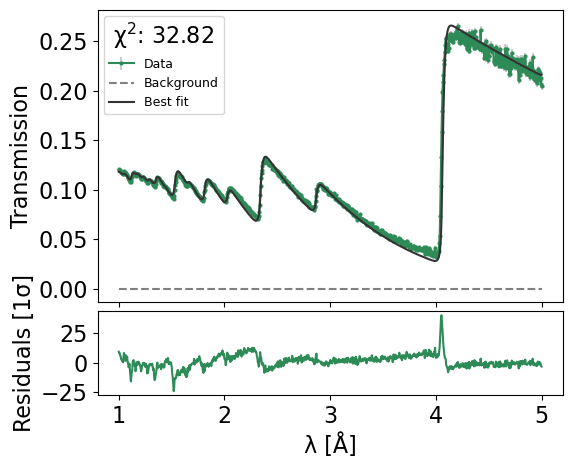

In [78]:
result.plot()

In [83]:
# Pulse duration values to test (µs)
pulse_durations = np.arange(10,1000,10)
results_pulse = []

for pulse_dur in pulse_durations:
    print(f"\nProcessing pulse_duration = {pulse_dur} µs...")
    
    try:
        # Create data object
        data = Data(
            signal_file='iron_powder.csv',
            openbeam_file='openbeam.csv',
            flux=5e6,
            duration=0.5,
            freq=20
        )
        
        # Process pipeline
        data.convolute_response(pulse_duration=pulse_dur)
        data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)  # 8 hours
        data.overlap(kernel=1, total_time=50, mode='equal')  # Single frame
        
        # Reconstruct
        recon = Reconstruct(data, tmin=None, tmax=None)
        recon.filter(kind='wiener', noise_power=1.0)
        
        # Get reconstruction statistics
        stats = recon.get_statistics()
        
        # nbragg fit with iron_with_cellulose model
        analysis = Analysis(
            xs='iron_cellulose_fixed_response',
            vary_background=False,
            vary_response=True,
            vary_weights=True,
            response="square_jorgensen",
            pulse_duration=pulse_dur
    
        )
        analysis.set_params(temp={'vary': False})  # Never vary temperature
        
        result = analysis.fit(recon, wlmin=1.0, wlmax=5.0)
        
        # Extract thickness
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0

        # Extract cellulose
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        
        # Store results
        results_pulse.append({
            'pulse_duration': pulse_dur,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err
        })
        
        print(f"  ✓ χ²/dof: {stats['chi2_per_dof']:.2f}, nbragg χ²: {result.redchi:.4f}, thickness: {thickness:.3f} ± {thickness_err:.3f} cm")
        
    except Exception as e:
        print(f"  ❌ Failed: {e}")
        import traceback
        traceback.print_exc()
        continue

# Convert to DataFrame
results_pulse_df = pd.DataFrame(results_pulse)
print("\nSweep complete!")
print(results_pulse_df)


Processing pulse_duration = 10 µs...
Pulse duration scaling applied: 10 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (10 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 1.00 × 0.000010
  duty_cycle = 0.000640
Generated equal kernel with 1 frames: [0.]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 0.00, nbragg χ²: 0.9832, thickness: 1.892 ± 0.016 cm

Processing pulse_duration = 20 µs...
Pulse duration scaling applied: 20 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (20 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 2.00 × 0.000010
  duty_cycle = 0.001280
Generated equal kernel with 1 frames: [0.]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


...

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 0.00, nbragg χ²: 3.1066, thickness: 1.975 ± 0.003 cm

Processing pulse_duration = 990 µs...
Pulse duration scaling applied: 990 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (990 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 99.00 × 0.000010
  duty_cycle = 0.063360
Generated equal kernel with 1 frames: [0.]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 0.00, nbragg χ²: 2.7103, thickness: 1.975 ± 0.003 cm

Sweep complete!
    pulse_duration  chi2_per_dof  r_squared  nbragg_redchi  thickness  \
0               10           0.0        1.0       0.983230   1.891945   
1               20           0.0        1.0       1.152048   1.898648   
2               30           0.0        1.0       1.126590   1.939380   
3               40           0.0        1.0       1.094446   1.958115   
4               50           0.0        1.0       1.101800   1.963079   
..             ...           ...        ...            ...        ...   
94             950           0.0        1.0       2.631110   1.975307   
95             960           0.0        1.0       2.612097   1.974766   
96             970           0.0        1.0       2.760825   1.974711   
97             980           0.0        1.0       3.106618   1.974560   
98             990           0.0        1.0       2.710257   1.975130   

    thickness_err  cellulose  cellulose_e

Text(0, 0.5, 'Thickness [cm]')

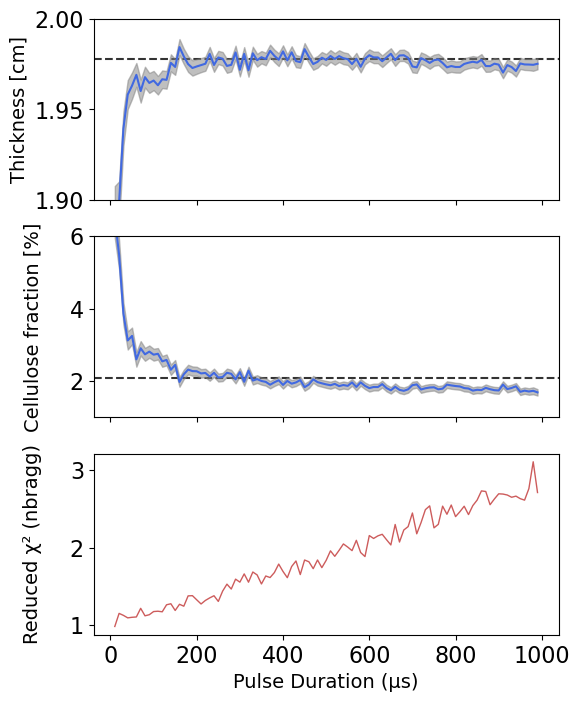

In [84]:
# Plot Study 1 results
fig, axes = plt.subplots(3, 1, figsize=(6, 8),sharex=True)


# nbragg reduced chi2
axes[2].plot(results_pulse_df['pulse_duration'], results_pulse_df['nbragg_redchi'], '-', color='indianred', linewidth=1, markersize=5)
# axes[1].set_xlabel('Pulse Duration (µs)', fontsize=11)
axes[2].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
# axes[1].set_title('nbragg Fit Quality', fontsize=12, fontweight='bold')
# axes[1].grid(True, alpha=0.3)


# Thickness
axes[1].plot(results_pulse_df['pulse_duration'], results_pulse_df['cellulose']*100,color="royalblue")
axes[1].fill_between(results_pulse_df['pulse_duration'],results_pulse_df["cellulose"]*100-results_pulse_df["cellulose_err"]*100,
                     results_pulse_df["cellulose"]*100+results_pulse_df["cellulose_err"]*100,
                     alpha=0.5,color="0.5",zorder=-1)
# axes[0].set_xlabel('Pulse Duration (µs)', fontsize=11)
axes[1].axhline(100*0.0208,ls="--",color="0.2",zorder=-2)
axes[1].set_ylim(1,6)
axes[1].set_ylabel('Cellulose fraction [%]\n',fontsize=14,)
# axes[0].set_title('Cellulose weight fraction', fontsize=12, fontweight='bold')
# axes[0].grid(True, alpha=0.3)


# Thickness
axes[0].plot(results_pulse_df['pulse_duration'], results_pulse_df['thickness'],color="royalblue")
axes[0].fill_between(results_pulse_df['pulse_duration'],results_pulse_df["thickness"]-results_pulse_df["thickness_err"],
                     results_pulse_df["thickness"]+results_pulse_df["thickness_err"],
                     alpha=0.5,color="0.5",zorder=-1)
axes[0].axhline(1.977588,ls="--",color="0.2",zorder=-2)
axes[0].set_ylim(1.9,2)
axes[2].set_xlabel('Pulse Duration (µs)',fontsize=14)
axes[0].set_ylabel('Thickness [cm]',fontsize=14)
# axes[2].set_title('Fitted Sample Thickness', fontsize=12, fontweight='bold')
# axes[2].grid(True, alpha=0.3)


## Study 2: Multiple Frames with 100 µs Pulse

Test reconstruction quality with varying number of frames at fixed pulse_duration=100 µs

In [102]:
# Number of frames to test
n_frames_values = range(1, 31)  # 1 to 10 frames
pulse_dur = 100  # µs
results_frames = []

for n_frames in n_frames_values:
    print(f"\nProcessing n_frames = {n_frames} (pulse = {pulse_dur} µs)...")
    
    try:
        # Create data object
        data = Data(
            signal_file='iron_powder.csv',
            openbeam_file='openbeam.csv',
            flux=5e6,
            duration=0.5,
            freq=20
        )
        
        # Process pipeline
        data.convolute_response(pulse_duration=pulse_dur)
        data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)  # 8 hours
        data.overlap(kernel=n_frames, total_time=50, mode='random', kernel_seed=42)
        
        # Reconstruct
        recon = Reconstruct(data, tmin=None, tmax=None)
        recon.filter(kind='wiener', noise_power=1.0)
        
        # Get reconstruction statistics
        stats = recon.get_statistics()
        
        # nbragg fit with iron_with_cellulose model
        analysis = Analysis(
            xs='iron_cellulose_fixed_response',
            vary_background=False,
            vary_response=True,
            vary_weights=True,
            response="square_jorgensen",
            pulse_duration=pulse_dur
    
        )
        analysis.set_params(temp={'vary': False})  # Never vary temperature
        
        result = analysis.fit(recon, wlmin=1.0, wlmax=2.5)
        
        # Extract thickness
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0

                # Extract cellulose
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        
        # Store results
        results_frames.append({
            'n_frames': n_frames,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err
        })
        
        print(f"  ✓ χ²/dof: {stats['chi2_per_dof']:.2f}, nbragg χ²: {result.redchi:.4f}, thickness: {thickness:.3f} ± {thickness_err:.3f} cm")
        
    except Exception as e:
        print(f"  ❌ Failed: {e}")
        import traceback
        traceback.print_exc()
        continue

# Convert to DataFrame
results_frames_df = pd.DataFrame(results_frames)
print("\nSweep complete!")
print(results_frames_df)


Processing n_frames = 1 (pulse = 100 µs)...
Pulse duration scaling applied: 100 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (100 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 10.00 × 0.000010
  duty_cycle = 0.006400
Generated random kernel with 1 frames: [0.]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 0.00, nbragg χ²: 1.2770, thickness: 2.001 ± 0.009 cm

Processing n_frames = 2 (pulse = 100 µs)...
Pulse duration scaling applied: 100 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (100 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 10.00 × 0.000010
  duty_cycle = 0.006400
Generated random kernel with 2 frames: [ 0.         47.53571532]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


...

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 93855494.41, nbragg χ²: 58.6714, thickness: 1.926 ± 0.032 cm

Processing n_frames = 30 (pulse = 100 µs)...
Pulse duration scaling applied: 100 µs (baseline: 10.0 µs)
Duty cycle calculation for PULSED source:
  duty_cycle = (flux_new / flux_orig) × (time_new / time_orig) × freq_new × (pulse_duration / baseline_duration) × (baseline_duration / 1e6)
  duty_cycle = (1.00e+06 / 5.00e+06) × (8.00h / 0.50h) × 20 × (100 / 10.0) × (10.0e-6)
  duty_cycle = 0.2000 × 16.0000 × 20 × 10.00 × 0.000010
  duty_cycle = 0.006400
Generated random kernel with 30 frames: [ 0.          2.32252064  2.90418061  6.97469303  7.79972602  7.80093202
  9.09124836  9.17022549  9.98368911 10.61695553 14.56145701 14.60723243
 15.21211215 18.31809216 18.72700594 21.59725093 22.80349921 25.71172192
 26.23782158 29.62072844 29.93292421 30.05575059 30.59264474 35.40362889
 36.59969709 39.25879807 41.62213204 43.30880729 47.53571532 48.49549261]


/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the iron phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/nbragg/models.py:1456: UserWarning: @CRYSEXTN section is not defined for the cellulose phase
  warnings.warn(f"@CRYSEXTN section is not defined for the {material} phase")
/opt/conda/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ χ²/dof: 134264703.13, nbragg χ²: 65.1417, thickness: 1.895 ± 0.028 cm

Sweep complete!
    n_frames  chi2_per_dof    r_squared  nbragg_redchi  thickness  \
0          1  0.000000e+00     1.000000       1.276998   2.001350   
1          2  2.059784e+02     0.335128       7.312261   1.934441   
2          3  2.510952e+04    -0.700886       2.187066   2.010972   
3          4  3.839654e+05    -3.475410       2.105238   1.948412   
4          5  5.868694e+05   -12.549077       3.898047   2.003153   
5          6  4.927288e+05   -13.295773       3.730156   1.973070   
6          7  1.731648e+06   -47.934575       5.219372   2.014732   
7          8  1.487419e+06   -49.347398       5.541560   1.981464   
8          9  3.360297e+06   -74.148137       5.612712   1.991338   
9         10  2.718023e+06  -104.774762       6.975828   2.012484   
10        11  6.469829e+06  -198.379760      12.342353   2.008828   
11        12  7.716645e+06  -250.481213      15.394847   2.002900   
12        13

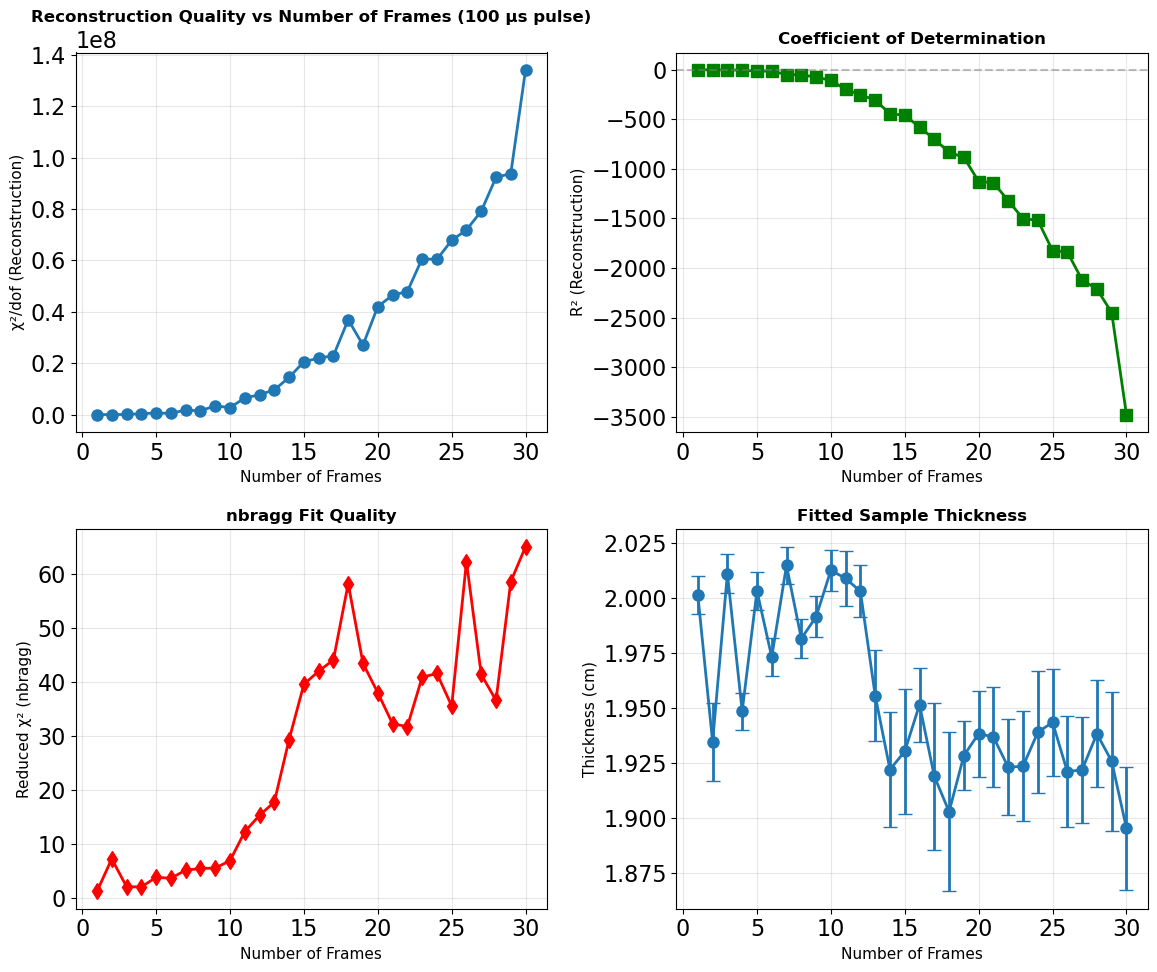


✓ Plot saved as n_frames_study.png


In [103]:
# Plot Study 2 results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Reconstruction chi2/dof
axes[0, 0].plot(results_frames_df['n_frames'], results_frames_df['chi2_per_dof'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Frames', fontsize=11)
axes[0, 0].set_ylabel('χ²/dof (Reconstruction)', fontsize=11)
axes[0, 0].set_title('Reconstruction Quality vs Number of Frames (100 µs pulse)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# R-squared
axes[0, 1].plot(results_frames_df['n_frames'], results_frames_df['r_squared'], 's-', color='green', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Number of Frames', fontsize=11)
axes[0, 1].set_ylabel('R² (Reconstruction)', fontsize=11)
axes[0, 1].set_title('Coefficient of Determination', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# nbragg reduced chi2
axes[1, 0].plot(results_frames_df['n_frames'], results_frames_df['nbragg_redchi'], 'd-', color='red', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Frames', fontsize=11)
axes[1, 0].set_ylabel('Reduced χ² (nbragg)', fontsize=11)
axes[1, 0].set_title('nbragg Fit Quality', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Thickness
axes[1, 1].errorbar(results_frames_df['n_frames'], results_frames_df['thickness'], 
                    yerr=results_frames_df['thickness_err'], fmt='o-', linewidth=2, markersize=8, capsize=5)
axes[1, 1].set_xlabel('Number of Frames', fontsize=11)
axes[1, 1].set_ylabel('Thickness (cm)', fontsize=11)
axes[1, 1].set_title('Fitted Sample Thickness', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n_frames_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved as n_frames_study.png")

In [ ]:
# Plot Study 1 results
fig, axes = plt.subplots(3, 1, figsize=(6, 8),sharex=True)


# nbragg reduced chi2
axes[2].plot(results_frames_df['n_frames'], results_frames_df['nbragg_redchi'], '-', color='indianred', linewidth=1, markersize=5)
# axes[1].set_xlabel('Pulse Duration (µs)', fontsize=11)
axes[2].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
# axes[1].set_title('nbragg Fit Quality', fontsize=12, fontweight='bold')
# axes[1].grid(True, alpha=0.3)


# Thickness
axes[1].plot(results_frames_df['n_frames'], results_frames_df['cellulose']*100,color="royalblue")
axes[1].fill_between(results_frames_df['n_frames'],results_frames_df["cellulose"]*100-results_frames_df["cellulose_err"]*100,
                     results_frames_df["cellulose"]*100+results_frames_df["cellulose_err"]*100,
                     alpha=0.5,color="0.5",zorder=-1)
# axes[0].set_xlabel('Pulse Duration (µs)', fontsize=11)
axes[1].axhline(100*0.0208,ls="--",color="0.2",zorder=-2)
# axes[1].set_ylim(1,6)
axes[1].set_ylabel('Cellulose fraction [%]\n',fontsize=14,)
# axes[0].set_title('Cellulose weight fraction', fontsize=12, fontweight='bold')
# axes[0].grid(True, alpha=0.3)


# Thickness
axes[0].plot(results_frames_df['n_frames'], results_frames_df['thickness'],color="royalblue")
axes[0].fill_between(results_frames_df['n_frames'],results_frames_df["thickness"]-results_frames_df["thickness_err"],
                     results_frames_df["thickness"]+results_frames_df["thickness_err"],
                     alpha=0.5,color="0.5",zorder=-1)
axes[0].axhline(1.977588,ls="--",color="0.2",zorder=-2)
# axes[0].set_ylim(1.9,2)
axes[2].set_xlabel('Number of random overlap frames',fontsize=14)
axes[0].set_ylabel('Thickness [cm]',fontsize=14)
# axes[2].set_title('Fitted Sample Thickness', fontsize=12, fontweight='bold')
# axes[2].grid(True, alpha=0.3)


## Summary

This notebook demonstrated:

### Study 1: Single Frame - Pulse Duration Effects
- Tested pulse durations: 10, 20, 50, 100, 150, 200 µs
- Single frame (no overlap)
- Shows how instrument resolution affects reconstruction and fitting

### Study 2: Multiple Frames at 100 µs Pulse
- Tested 1-10 random frames
- Fixed pulse duration: 100 µs
- Shows trade-off between frame overlap and reconstruction quality

### nbragg Fit Settings (Used in Both Studies)
- **Model**: iron_with_cellulose
- **vary_background**: True
- **vary_response**: False
- **vary_weights**: True
- **vary_temperature**: False (never varied)
- **Wavelength range**: 1-5 Å

### Key Observations
- Longer pulse durations blur the Bragg edges but may improve statistics
- More frames generally improve reconstruction but increase complexity
- The iron_with_cellulose model accounts for cellulose impurities in the sample

### Next Steps
- Try `iron_cellulose_fixed_response` model for faster fitting
- Experiment with different kernel modes: `mode='equal'` or `mode='blue_noise'`
- Test different `noise_power` values for the Wiener filter